In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\PC-LOQ\Desktop\internship\day8()\diabetes_prediction_dataset.csv\diabetes_prediction_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
(100000, 9)
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [2]:
print(df.isnull().sum())
print(df.info())
print(df.describe())
print(df["diabetes"].value_counts())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None
                 age  hyp

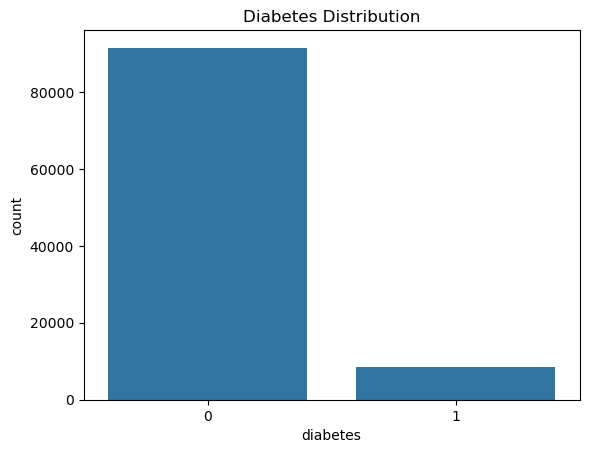

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x="diabetes",
    data=df
)
plt.title("Diabetes Distribution")
plt.show()

In [4]:
print(df["gender"].unique())
print(df["smoking_history"].unique())

['Female' 'Male' 'Other']
['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [5]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df["gender"] = le_gender.fit_transform(df["gender"])

le_smoking = LabelEncoder()
df["smoking_history"] = le_smoking.fit_transform(df["smoking_history"])

print(df.head())

   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0       0  80.0             0              1                4  25.19   
1       0  54.0             0              0                0  27.32   
2       1  28.0             0              0                4  27.32   
3       0  36.0             0              0                1  23.45   
4       1  76.0             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [6]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
print("Logistic Accuracy =", acc_lr)

Logistic Accuracy = 0.95865


In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, pred_knn)
print("KNN Accuracy =", acc_knn)

KNN Accuracy = 0.96125


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)
print("Decision Tree Accuracy =", acc_dt)

Decision Tree Accuracy = 0.95235


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
print("Random Forest Accuracy =", acc_rf)

Random Forest Accuracy = 0.97075


In [13]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(random_state=42)
ab.fit(X_train, y_train)

pred_ab = ab.predict(X_test)
acc_ab = accuracy_score(y_test, pred_ab)
print("AdaBoost Accuracy =", acc_ab)

AdaBoost Accuracy = 0.97215


In [14]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "AdaBoost"
    ],

    "Accuracy":[
        acc_lr,
        acc_knn,
        acc_dt,
        acc_rf,
        acc_ab
    ]
})
print(results)

                 Model  Accuracy
0  Logistic Regression   0.95865
1                  KNN   0.96125
2        Decision Tree   0.95235
3        Random Forest   0.97075
4             AdaBoost   0.97215


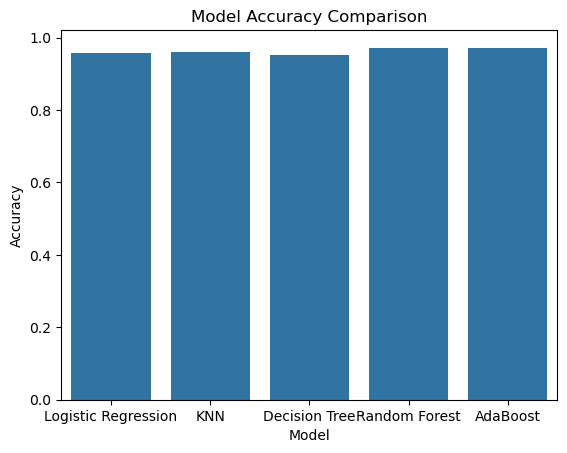

In [15]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.show()